RGB A HSV

In [24]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np
imagen1=cv2.imread('imagen.jpg')
img=cv2.cvtColor(imagen1,cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        img2= new_img[...,0] < 0
        new_img[img2,0]   =  new_img[img2,0] + 360
    return new_img

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_2988\3261535817.py:32: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


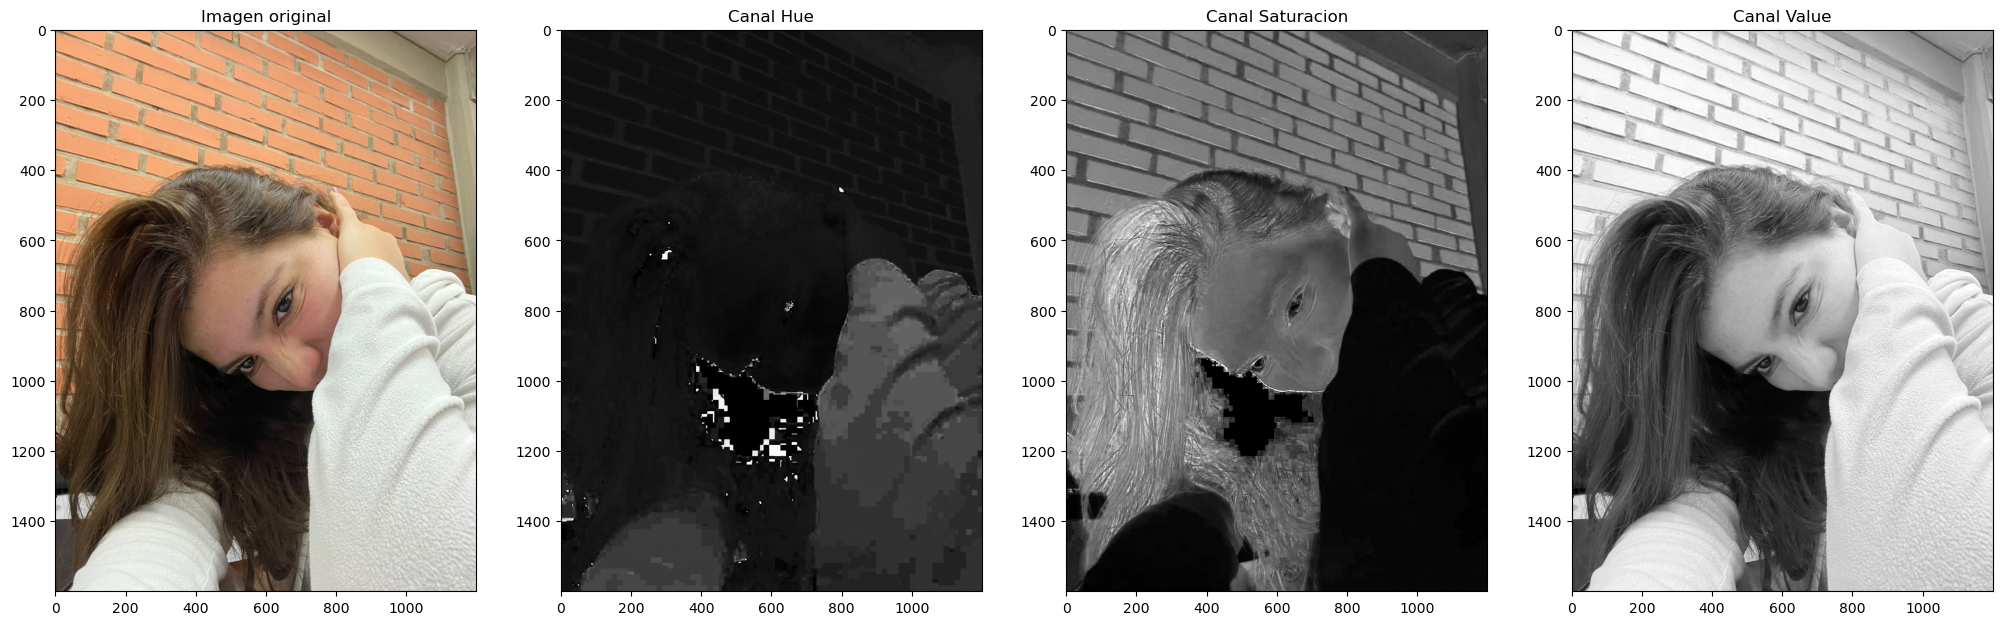

In [25]:
hsv_img = RGB2HSV(img)

fig, axs = plt.subplots(1,4,figsize=(25,10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturacion')

axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

plt.show()

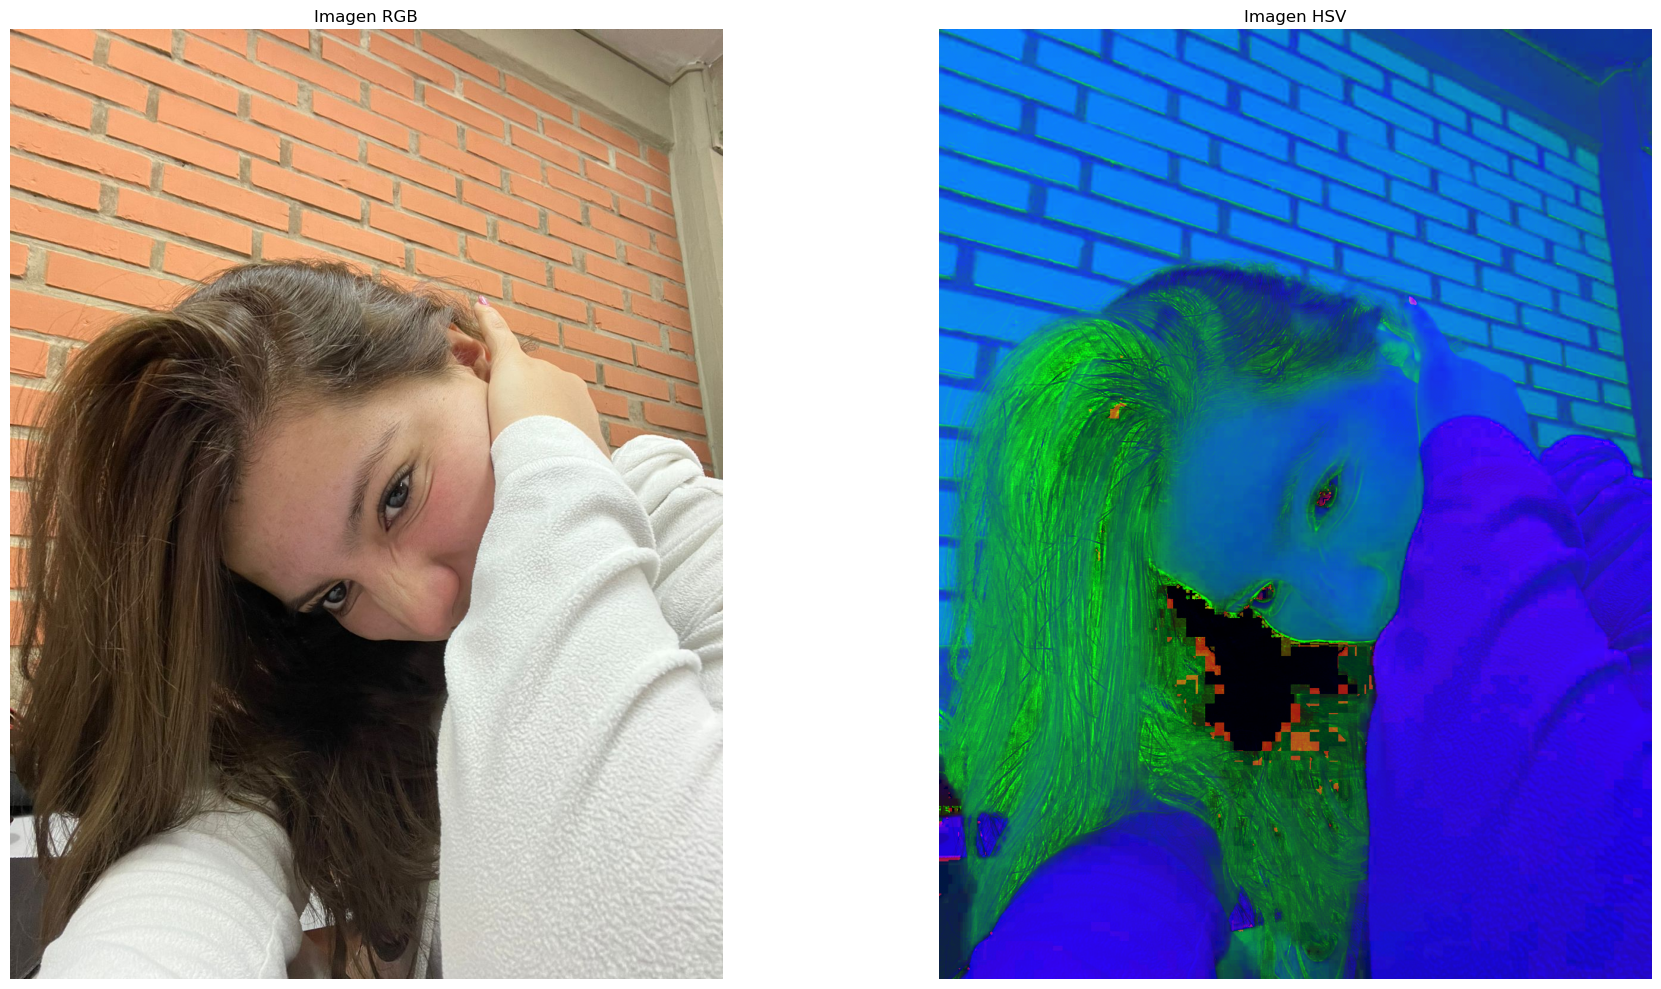

In [26]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

img_rgb = cv2.cvtColor(cv2.imread('imagen.jpg', cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen RGB')
axs[0].axis('off')

axs[1].imshow(img_hsv)
axs[1].set_title('Imagen HSV')
axs[1].axis('off')

plt.tight_layout()
plt.show()

HSV A RGB


In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    img_bgr = cv2.imread('imagen.jpg')
    if img_bgr is None:
        raise FileNotFoundError("No se encontró 'imagen.jpg'")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = img_rgb.astype(np.float32) / 255.0
except Exception as e:
    print(f"Error: {e}")
    img_rgb = np.zeros((100, 100, 3), dtype=np.float32)

def RGB2HSV(img):
    h_img, w_img, _ = img.shape
    hsv = np.zeros_like(img)

    for i in range(h_img):
        for j in range(w_img):
            r, g, b = img[i, j]
            cmax = max(r, g, b)
            cmin = min(r, g, b)
            delta = cmax - cmin

            if delta == 0:
                H = 0
            elif cmax == r:
                H = 60 * (((g - b) / delta) % 6)
            elif cmax == g:
                H = 60 * (((b - r) / delta) + 2)
            elif cmax == b:
                H = 60 * (((r - g) / delta) + 4)
            
            S = 0 if cmax == 0 else delta / cmax

            V = cmax

            hsv[i, j] = [H, S, V]
    return hsv

def HSV2RGB(hsv):
    h_img, w_img, _ = hsv.shape
    rgb_final = np.zeros_like(hsv)

    for i in range(h_img):
        for j in range(w_img):
            H, S, V = hsv[i, j]

            # Fórmulas de la ingeniera:
            C = V * S  # Componente base
            # Usar 60.0 para asegurar división flotante en el mod 2
            X = C * (1 - abs((H / 60.0) % 2 - 1)) 
            m = V - C  # Ajuste de brillo mínimo

            # Determinación de R', G', B' según sector de H
            if 0 <= H < 60:
                r_p, g_p, b_p = C, X, 0
            elif 60 <= H < 120:
                r_p, g_p, b_p = X, C, 0
            elif 120 <= H < 180:
                r_p, g_p, b_p = 0, C, X
            elif 180 <= H < 240:
                r_p, g_p, b_p = 0, X, C
            elif 240 <= H < 300:
                r_p, g_p, b_p = X, 0, C
            else: # 300 <= H < 360
                r_p, g_p, b_p = C, 0, X

            rgb_final[i, j] = [(r_p + m) * 255, (g_p + m) * 255, (b_p + m) * 255]

    return rgb_final

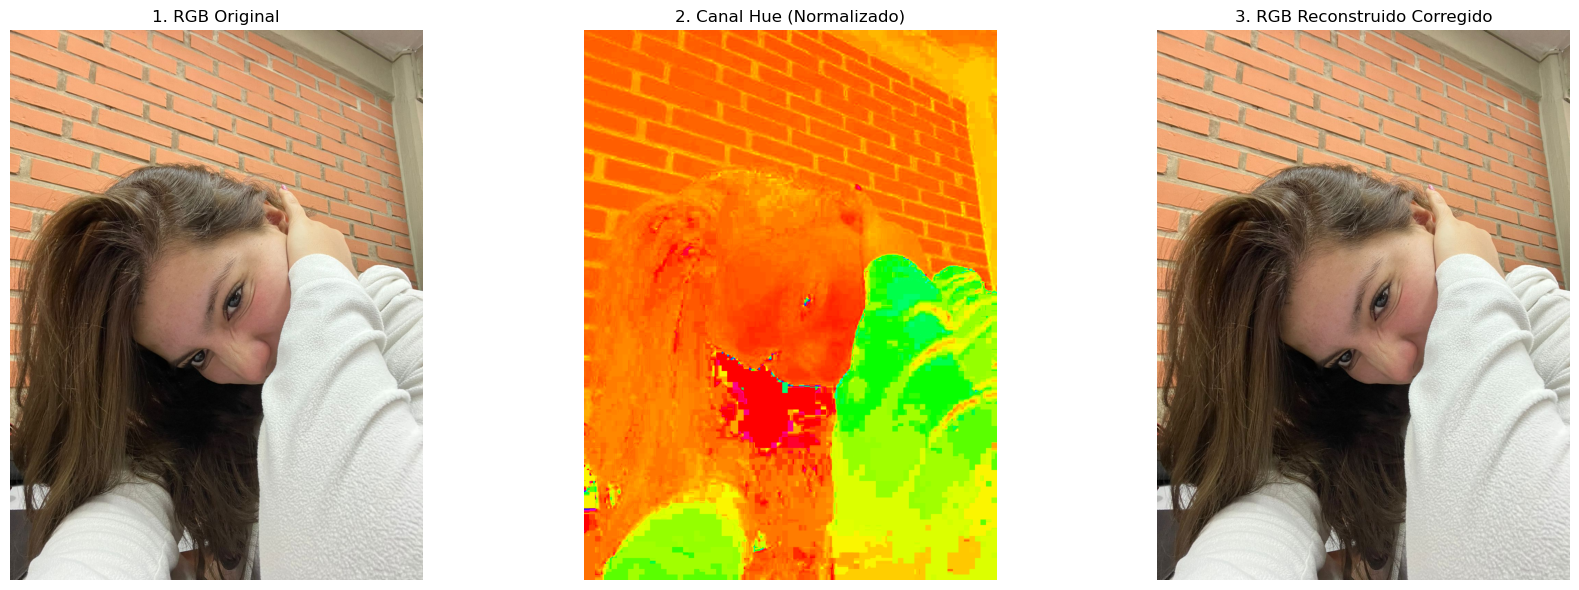

In [33]:
hsv_img = RGB2HSV(img_rgb)
rgb_reconstruido_raw = HSV2RGB(hsv_img)

rgb_reconstruido = np.clip(rgb_reconstruido_raw, 0, 255).astype(np.uint8)
img_original_display = (img_rgb * 255).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(img_original_display)
axs[0].set_title("1. RGB Original")
axs[0].axis("off")

axs[1].imshow(hsv_img[..., 0] / 360.0, cmap='hsv')
axs[1].set_title("2. Canal Hue (Normalizado)")
axs[1].axis("off")

axs[2].imshow(rgb_reconstruido)
axs[2].set_title("3. RGB Reconstruido Corregido")
axs[2].axis("off")

plt.tight_layout()
plt.show()